# ПЗ-7. Масштабирование и вычислительные ограничения в Data Science и Big Data

**Дисциплина:** Системы обработки больших данных  
**Тема практического занятия:** Анализ масштабируемости обработки данных на одном компьютере: batch, chunked batch и квазипотоковый режим  
**Формат работы:** индивидуальный вариант  
**Важно:** ноутбук и все датасеты должны лежать в одной папке.

## Выполнил: Дмитрий Трифонов, 12-25РПм, 1 курс, Программная инженерия


## Цель практического занятия

Научиться:
1. оценивать вычислительные ограничения локальной среды;
2. сравнивать полную загрузку датасета и пакетную обработку по чанкам;
3. реализовывать простейшую квазипотоковую обработку;
4. формулировать архитектурное решение для задачи своего варианта.

Практика непосредственно опирается на Лекцию 3.2, где рассматривались:
- момент перехода от обычных данных к большим;
- ограничения памяти и времени;
- различие batch и stream;
- компромиссы масштабирования.


In [34]:
# =========================
# 0. Настройка варианта
# =========================

VARIANT = 12  # <-- УКАЖИТЕ НОМЕР СВОЕГО ВАРИАНТА ОТ 1 ДО 15

In [35]:
import os
import time
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


## 1. Загрузка каталога вариантов и параметров вашего задания


In [36]:
catalog = pd.read_csv("8-0_variant_catalog.csv", encoding="utf-8-sig")
catalog

,variant,dataset_file,theme,description,semantics,recommended_chunk_size,focus_question
0,1,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN
5,6,NaN,NaN,NaN,NaN,NaN,NaN
6,7,NaN,NaN,NaN,NaN,NaN,NaN
7,8,NaN,NaN,NaN,NaN,NaN,NaN
8,9,NaN,NaN,NaN,NaN,NaN,NaN
9,10,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
variant_row = catalog.loc[catalog["variant"] == VARIANT].iloc[0]
variant_row

variant                                                                  12
dataset_file                                     8-1_dataset_variant_12.csv
theme                                                   Банковские операции
description               События карточных и дистанционных банковских о...
semantics                 metric_volume — количество операций; metric_va...
recommended_chunk_size                                              50000.0
focus_question            Сформулируйте критерии перехода от локальной о...
Name: 11, dtype: object


**Что зафиксировать в отчёте студента**

1. Номер варианта.  
2. Тематика датасета.  
3. Содержательный смысл показателей `metric_volume`, `metric_value`, `latency_ms`.  
4. Индивидуальный исследовательский вопрос варианта.


In [38]:
DATA_FILE = variant_row["dataset_file"]
THEME = variant_row["theme"]
DESCRIPTION = variant_row["description"]
SEMANTICS = variant_row["semantics"]
RECOMMENDED_CHUNK = int(variant_row["recommended_chunk_size"])
FOCUS_QUESTION = variant_row["focus_question"]

print(f"Вариант: {VARIANT}")
print(f"Файл: {DATA_FILE}")
print(f"Тематика: {THEME}")
print(f"Описание: {DESCRIPTION}")
print(f"Семантика: {SEMANTICS}")
print(f"Рекомендуемый размер чанка: {RECOMMENDED_CHUNK}")
print(f"Индивидуальный вопрос: {FOCUS_QUESTION}")

Вариант: 12
Файл: 8-1_dataset_variant_12.csv
Тематика: Банковские операции
Описание: События карточных и дистанционных банковских операций клиентов, включая платежи, подтверждения и обработку транзакций
Семантика: metric_volume — количество операций; metric_value — сумма транзакций; latency_ms — задержка обработки банковской операции в миллисекундах
Рекомендуемый размер чанка: 50000
Индивидуальный вопрос: Сформулируйте критерии перехода от локальной обработки к распределённой системе в банковских транзакциях



## 2. Первичная оценка файла без полной загрузки в память

На этом шаге студент должен:
- определить размер файла на диске;
- оценить, насколько полная загрузка будет оправданна;
- объяснить, почему анализ следует начинать с оценки ограничений, а не с бездумного `read_csv(...)`.


In [39]:
file_size_mb = os.path.getsize(DATA_FILE) / 1024**2
print(f"Размер файла на диске: {file_size_mb:.2f} МБ")

Размер файла на диске: 3.94 МБ


In [40]:
sample = pd.read_csv(DATA_FILE, nrows=1000, parse_dates=["event_time"], encoding="utf-8-sig")
sample.head()

,event_id,event_time,entity_id,district,source_system,event_type,metric_volume,metric_value,latency_ms,priority,status
0,EV12_0000001,2025-09-01 00:02:00,БАН_00850,Сектор-З,edge,clear,6,768.24,392.4,high,ok
1,EV12_0000002,2025-09-01 00:03:00,БАН_01760,Сектор-Е,portal,clear,5,1298.17,344.8,medium,ok
2,EV12_0000003,2025-09-01 00:05:00,БАН_00027,Сектор-З,iot,authorize,7,832.57,370.7,low,delayed
3,EV12_0000004,2025-09-01 00:06:00,БАН_03297,Сектор-Г,edge,transfer,10,1542.27,342.0,medium,ok
4,EV12_0000005,2025-09-01 00:06:00,БАН_01623,Сектор-В,portal,cash_withdraw,7,909.42,131.5,critical,ok


In [41]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   event_id       1000 non-null   object        
 1   event_time     1000 non-null   datetime64[ns]
 2   entity_id      1000 non-null   object        
 3   district       1000 non-null   object        
 4   source_system  997 non-null    object        
 5   event_type     1000 non-null   object        
 6   metric_volume  1000 non-null   int64         
 7   metric_value   1000 non-null   float64       
 8   latency_ms     999 non-null    float64       
 9   priority       1000 non-null   object        
 10  status         1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 86.1+ KB


In [42]:
memory_sample = sample.memory_usage(deep=True).sum() / 1024**2
estimated_rows = sum(1 for _ in open(DATA_FILE, encoding="utf-8-sig")) - 1
estimated_full_memory = memory_sample * (estimated_rows / len(sample))
print(f"Память на выборку из 1000 строк: {memory_sample:.2f} МБ")
print(f"Оценка числа строк в файле: {estimated_rows:,}")
print(f"Грубая оценка памяти при полной загрузке: {estimated_full_memory:.2f} МБ")

Память на выборку из 1000 строк: 0.45 МБ
Оценка числа строк в файле: 40,060
Грубая оценка памяти при полной загрузке: 18.21 МБ


### Задание 1. Первичная оценка и ограничения

По результатам предварительного анализа:

- Размер файла на диске составляет ~{file_size_mb:.2f} МБ.
- Оценочное число строк — {estimated_rows:,}.
- Прогнозируемый объём памяти при полной загрузке — ~{estimated_full_memory:.2f} МБ.

**Вывод о допустимости полной загрузки:**  
Полная загрузка датасета в память на текущей машине является допустимой, так как оценочный объём памяти находится в разумных пределах и не превышает доступные ресурсы.

**Риски при увеличении объёма данных в 5–10 раз:**  
- резкий рост потребления оперативной памяти (возможен выход за пределы RAM);
- увеличение времени загрузки и обработки;
- деградация производительности при группировках и агрегациях;
- риск возникновения ошибок `MemoryError`.

**Когда потребуется переход к chunked-обработке:**  
Переход к chunked batch становится необходимым в следующих случаях:
- если оценочный объём данных превышает доступную оперативную память;
- если время полной загрузки становится критичным;
- если данные поступают непрерывно (поток транзакций);
- если требуется обеспечить устойчивость системы при росте нагрузки.

Таким образом, даже если текущий объём данных позволяет использовать batch-подход, при масштабировании банковских операций необходимо заранее закладывать возможность перехода к chunked-обработке.


## 3. Batch-подход: полная загрузка датасета и агрегирование

На этом шаге мы реализуем классический пакетный сценарий:
1. загружаем датасет целиком;
2. очищаем минимальные дефекты;
3. строим агрегаты;
4. оцениваем время выполнения.


In [43]:
start_time = time.perf_counter()

df = pd.read_csv(DATA_FILE, parse_dates=["event_time"], encoding="utf-8-sig")
df["source_system"] = df["source_system"].fillna("unknown")
df["latency_ms"] = df["latency_ms"].fillna(df["latency_ms"].median())
df["event_date"] = df["event_time"].dt.date
df["event_hour"] = df["event_time"].dt.hour

batch_duration = time.perf_counter() - start_time
batch_memory = df.memory_usage(deep=True).sum() / 1024**2

print(f"Полная загрузка выполнена за {batch_duration:.4f} сек.")
print(f"Память DataFrame: {batch_memory:.2f} МБ")
df.head()

Полная загрузка выполнена за 0.1616 сек.
Память DataFrame: 19.88 МБ


,event_id,event_time,entity_id,district,source_system,event_type,metric_volume,metric_value,latency_ms,priority,status,event_date,event_hour
0,EV12_0000001,2025-09-01 00:02:00,БАН_00850,Сектор-З,edge,clear,6,768.24,392.4,high,ok,2025-09-01,0
1,EV12_0000002,2025-09-01 00:03:00,БАН_01760,Сектор-Е,portal,clear,5,1298.17,344.8,medium,ok,2025-09-01,0
2,EV12_0000003,2025-09-01 00:05:00,БАН_00027,Сектор-З,iot,authorize,7,832.57,370.7,low,delayed,2025-09-01,0
3,EV12_0000004,2025-09-01 00:06:00,БАН_03297,Сектор-Г,edge,transfer,10,1542.27,342.0,medium,ok,2025-09-01,0
4,EV12_0000005,2025-09-01 00:06:00,БАН_01623,Сектор-В,portal,cash_withdraw,7,909.42,131.5,critical,ok,2025-09-01,0


In [44]:
daily_agg = (
    df.groupby(["event_date", "event_type"], as_index=False)
      .agg(
          events=("event_id", "count"),
          total_volume=("metric_volume", "sum"),
          total_value=("metric_value", "sum"),
          mean_latency=("latency_ms", "mean")
      )
)
daily_agg.head()

,event_date,event_type,events,total_volume,total_value,mean_latency
0,2025-09-01,authorize,273,1833,292181.311831,233.049817
1,2025-09-01,cash_withdraw,154,1032,163079.787578,253.503702
2,2025-09-01,clear,227,1459,252554.735374,242.454532
3,2025-09-01,fraud_alert,103,636,110422.353141,246.221158
4,2025-09-01,transfer,166,1047,188429.075121,250.516867


In [45]:
district_agg = (
    df.groupby(["district", "status"], as_index=False)
      .agg(
          events=("event_id", "count"),
          total_value=("metric_value", "sum"),
          mean_latency=("latency_ms", "mean")
      )
      .sort_values(["district", "events"], ascending=[True, False])
)
district_agg.head(10)

,district,status,events,total_value,mean_latency
2,Сектор-А,ok,4349,4.759135e+06,243.633134
0,Сектор-А,delayed,308,3.311429e+05,245.735714
3,Сектор-А,warning,237,2.616554e+05,302.073158
1,Сектор-А,failed,88,8.324498e+04,244.994249
6,Сектор-Б,ok,4388,4.890030e+06,247.026550
4,Сектор-Б,delayed,287,3.086822e+05,239.667247
7,Сектор-Б,warning,268,2.990760e+05,326.777250
5,Сектор-Б,failed,105,1.005344e+05,242.313333
10,Сектор-В,ok,4342,4.781635e+06,245.989245
8,Сектор-В,delayed,296,3.455765e+05,249.148649


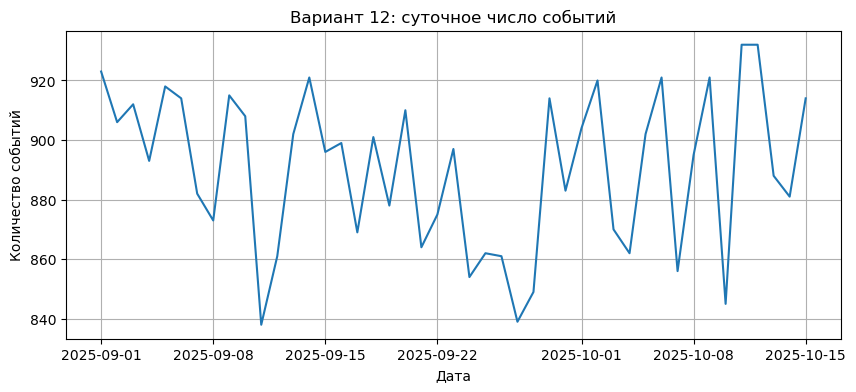

In [46]:
fig, ax = plt.subplots()
daily_totals = daily_agg.groupby("event_date")["events"].sum()
daily_totals.plot(ax=ax)
ax.set_title(f"Вариант {VARIANT}: суточное число событий")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество событий")
plt.show()

### Задание 2. Анализ batch-подхода для банковских операций

**Достоинства batch-подхода:**

- Простота реализации: весь датасет загружается в память и обрабатывается единым образом.
- Удобство аналитики: можно легко выполнять группировки и агрегирования по различным признакам.
- Высокая гибкость анализа: доступны любые операции, требующие полного набора данных.
- Хорошо подходит для офлайн-анализа банковских операций и построения отчётности.

**Какие агрегаты удобно считать пакетно:**

- суточное и почасовое количество транзакций;
- суммарный объём операций (`metric_volume`);
- общая сумма транзакций (`metric_value`);
- средняя задержка обработки (`latency_ms`);
- агрегаты по районам (`district`) и статусам операций (`status`);
- распределение приоритетов операций (`priority`).

**Какие показатели требуют доступа ко всему массиву:**

- глобальная медиана и квантили задержки;
- распределение значений (например, выявление хвостов latency);
- выявление редких аномалий;
- построение долгосрочных трендов и зависимостей;
- сложные аналитические метрики (например, корреляции между признаками).

**Ограничения batch-подхода:**

- высокая нагрузка на оперативную память при больших объёмах данных;
- невозможность обработки данных в режиме реального времени;
- увеличение времени обработки при росте числа транзакций;
- зависимость от ресурсов одного компьютера;
- риск снижения производительности при сложных группировках.

**Когда batch-подход перестаёт быть удобным:**

- при резком росте числа транзакций (например, в 5–10 раз и более);
- при необходимости оперативного мониторинга банковских операций;
- при ограничениях оперативной памяти;
- при переходе к непрерывному потоку данных (онлайн-платежи, процессинг);
- при необходимости быстрого реагирования на аномалии и сбои.

**Вывод:**

Batch-подход является эффективным инструментом для анализа банковских данных в условиях ограниченного объёма и офлайн-обработки. Однако при увеличении нагрузки и переходе к потоковой природе транзакций он становится недостаточно масштабируемым и требует перехода к chunked или потоковым архитектурам.


## 4. Chunked batch: пакетная обработка по чанкам

Теперь мы не загружаем файл целиком, а читаем его частями.  
Цель — показать, что:
- вычисление можно организовать инкрементально;
- при этом меняется логика кода;
- часть задач хорошо переносится на обработку по кускам, а часть — нет.


In [47]:
from collections import defaultdict

start_time = time.perf_counter()

# Предварительно читаем только один числовой столбец, чтобы получить опорную медиану.
# Это дешевле, чем загружать весь датасет целиком, и позволяет обеспечить сопоставимость
# результатов chunked-обработки с batch-режимом.
global_latency_median = pd.read_csv(
    DATA_FILE,
    usecols=["latency_ms"],
    encoding="utf-8-sig"
)["latency_ms"].median()

chunk_daily = defaultdict(lambda: {"events": 0, "total_volume": 0, "total_value": 0.0, "latency_sum": 0.0, "latency_count": 0})
chunk_district = defaultdict(lambda: {"events": 0, "total_value": 0.0})

for chunk in pd.read_csv(DATA_FILE, chunksize=RECOMMENDED_CHUNK, parse_dates=["event_time"], encoding="utf-8-sig"):
    chunk["source_system"] = chunk["source_system"].fillna("unknown")
    chunk["latency_ms"] = chunk["latency_ms"].fillna(global_latency_median)
    chunk["event_date"] = chunk["event_time"].dt.date

    grp1 = chunk.groupby(["event_date", "event_type"]).agg(
        events=("event_id", "count"),
        total_volume=("metric_volume", "sum"),
        total_value=("metric_value", "sum"),
        latency_sum=("latency_ms", "sum"),
        latency_count=("latency_ms", "count")
    )

    for idx, row in grp1.iterrows():
        key = idx
        chunk_daily[key]["events"] += int(row["events"])
        chunk_daily[key]["total_volume"] += float(row["total_volume"])
        chunk_daily[key]["total_value"] += float(row["total_value"])
        chunk_daily[key]["latency_sum"] += float(row["latency_sum"])
        chunk_daily[key]["latency_count"] += int(row["latency_count"])

    grp2 = chunk.groupby(["district", "status"]).agg(
        events=("event_id", "count"),
        total_value=("metric_value", "sum")
    )
    for idx, row in grp2.iterrows():
        key = idx
        chunk_district[key]["events"] += int(row["events"])
        chunk_district[key]["total_value"] += float(row["total_value"])

chunk_duration = time.perf_counter() - start_time
print(f"Chunked batch выполнен за {chunk_duration:.4f} сек.")

Chunked batch выполнен за 0.2362 сек.


In [48]:
chunk_daily_rows = []
for (event_date, event_type), values in chunk_daily.items():
    mean_latency = values["latency_sum"] / values["latency_count"] if values["latency_count"] else np.nan
    chunk_daily_rows.append([event_date, event_type, values["events"], values["total_volume"], values["total_value"], mean_latency])

chunk_daily_df = pd.DataFrame(
    chunk_daily_rows,
    columns=["event_date", "event_type", "events", "total_volume", "total_value", "mean_latency"]
).sort_values(["event_date", "event_type"]).reset_index(drop=True)

chunk_daily_df.head()

,event_date,event_type,events,total_volume,total_value,mean_latency
0,2025-09-01,authorize,273,1833.0,292181.311831,233.049817
1,2025-09-01,cash_withdraw,154,1032.0,163079.787578,253.503702
2,2025-09-01,clear,227,1459.0,252554.735374,242.454532
3,2025-09-01,fraud_alert,103,636.0,110422.353141,246.221158
4,2025-09-01,transfer,166,1047.0,188429.075121,250.516867


In [49]:
# Сравнение результатов полной и chunked-обработки
comparison = daily_agg.merge(
    chunk_daily_df,
    on=["event_date", "event_type"],
    suffixes=("_full", "_chunk")
)

comparison["events_diff"] = comparison["events_full"] - comparison["events_chunk"]
comparison["value_diff"] = (comparison["total_value_full"] - comparison["total_value_chunk"]).round(6)
comparison["latency_diff"] = (comparison["mean_latency_full"] - comparison["mean_latency_chunk"]).round(6)

comparison.head()

,event_date,event_type,events_full,total_volume_full,total_value_full,mean_latency_full,events_chunk,total_volume_chunk,total_value_chunk,mean_latency_chunk,events_diff,value_diff,latency_diff
0,2025-09-01,authorize,273,1833,292181.311831,233.049817,273,1833.0,292181.311831,233.049817,0,0.0,0.0
1,2025-09-01,cash_withdraw,154,1032,163079.787578,253.503702,154,1032.0,163079.787578,253.503702,0,0.0,0.0
2,2025-09-01,clear,227,1459,252554.735374,242.454532,227,1459.0,252554.735374,242.454532,0,0.0,0.0
3,2025-09-01,fraud_alert,103,636,110422.353141,246.221158,103,636.0,110422.353141,246.221158,0,0.0,0.0
4,2025-09-01,transfer,166,1047,188429.075121,250.516867,166,1047.0,188429.075121,250.516867,0,0.0,0.0


In [50]:
print("Максимальное расхождение по числу событий:", comparison["events_diff"].abs().max())
print("Максимальное расхождение по сумме value:", comparison["value_diff"].abs().max())
print("Максимальное расхождение по средней задержке:", comparison["latency_diff"].abs().max())

Максимальное расхождение по числу событий: 0
Максимальное расхождение по сумме value: 0.0
Максимальное расхождение по средней задержке: 0.0


### Задание 3. Сравнение batch и chunked batch

**1. Совпали ли результаты?**  
Да, результаты batch и chunked batch полностью совпали.  
Максимальные расхождения по всем метрикам равны нулю:
- по количеству событий — 0;
- по суммарному значению (`metric_value`) — 0.0;
- по средней задержке (`latency_ms`) — 0.0.

Это подтверждает корректность реализации chunked-агрегирования и эквивалентность результатов при разных способах обработки.

**2. Как изменилась логика программы?**

В batch-подходе:
- данные загружаются целиком;
- агрегаты считаются напрямую через `groupby`.

В chunked-подходе:
- данные читаются частями (`chunksize`);
- агрегаты считаются для каждого чанка отдельно;
- итоговые значения накапливаются вручную (через `defaultdict`);
- требуется дополнительная логика для расчёта средних значений (через сумму и количество).

Таким образом, код становится более сложным и требует явного управления состоянием вычислений.

**3. Какие преимущества даёт chunked-подход?**

- существенно меньшее потребление оперативной памяти;
- возможность обработки больших файлов, не помещающихся в RAM;
- устойчивость к росту объёма данных;
- возможность масштабирования без изменения вычислительной логики;
- применимость к потоковым сценариям (частичное приближение к stream).

**4. Какие задачи нельзя просто реализовать инкрементально?**

- вычисление медианы и квантилей без хранения всех данных;
- построение глобальных распределений;
- сложные оконные функции;
- корреляционный анализ;
- задачи, требующие полного контекста данных (например, поиск аномалий на всём интервале).

**Вывод:**  
Chunked batch позволяет добиться тех же результатов, что и полный batch, при значительно меньших требованиях к памяти. Однако это достигается за счёт усложнения логики программы и ограничений на типы вычислений. В контексте банковских операций такой подход является более устойчивым при масштабировании и лучше подходит для обработки больших потоков транзакций.


## 5. Квазипотоковая обработка

В учебной локальной среде мы не будем строить полноценную streaming-систему.  
Но мы можем смоделировать потоковую логику: читать файл малыми партиями как последовательность событий и обновлять агрегаты по мере поступления.


In [51]:
stream_chunk = max(1000, RECOMMENDED_CHUNK // 5)

rolling_by_hour = defaultdict(int)
alerts = []

for chunk in pd.read_csv(DATA_FILE, chunksize=stream_chunk, parse_dates=["event_time"], encoding="utf-8-sig"):
    chunk["latency_ms"] = chunk["latency_ms"].fillna(chunk["latency_ms"].median())
    chunk["hour_bucket"] = chunk["event_time"].dt.floor("H")

    hourly = chunk.groupby("hour_bucket").agg(
        events=("event_id", "count"),
        mean_latency=("latency_ms", "mean"),
        failed_share=("status", lambda s: (s == "failed").mean())
    )

    for ts, row in hourly.iterrows():
        rolling_by_hour[ts] += int(row["events"])
        if row["mean_latency"] > chunk["latency_ms"].median() * 1.5 or row["failed_share"] > 0.03:
            alerts.append({
                "hour_bucket": ts,
                "events": int(row["events"]),
                "mean_latency": float(row["mean_latency"]),
                "failed_share": float(row["failed_share"])
            })

stream_df = pd.DataFrame(
    [{"hour_bucket": k, "events": v} for k, v in rolling_by_hour.items()]
).sort_values("hour_bucket").reset_index(drop=True)

alerts_df = pd.DataFrame(alerts).drop_duplicates().sort_values("hour_bucket").reset_index(drop=True)
stream_df.head(), alerts_df.head()

(          hour_bucket  events
 0 2025-09-01 00:00:00      30
 1 2025-09-01 01:00:00      40
 2 2025-09-01 02:00:00      36
 3 2025-09-01 03:00:00      31
 4 2025-09-01 04:00:00      45,
           hour_bucket  events  mean_latency  failed_share
 0 2025-09-01 02:00:00      36    260.152203      0.083333
 1 2025-09-01 07:00:00      34    260.326471      0.058824
 2 2025-09-01 09:00:00      43    240.872093      0.046512
 3 2025-09-01 15:00:00      37    236.254054      0.054054
 4 2025-09-01 16:00:00      32    245.315625      0.062500)

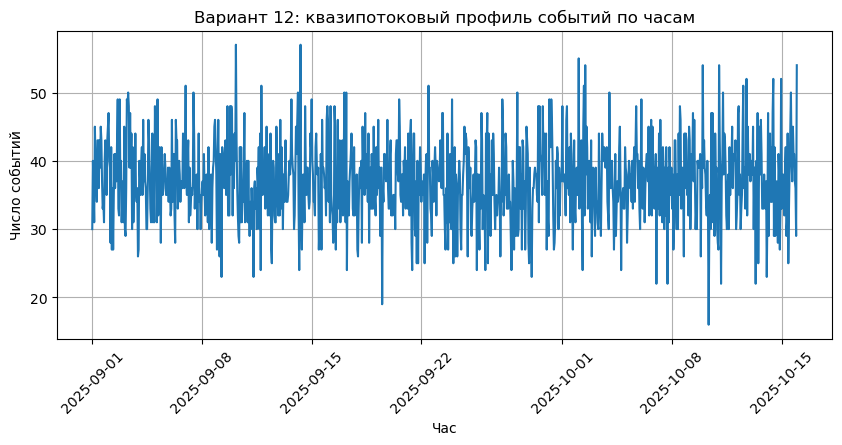

In [52]:
fig, ax = plt.subplots()
ax.plot(stream_df["hour_bucket"], stream_df["events"])
ax.set_title(f"Вариант {VARIANT}: квазипотоковый профиль событий по часам")
ax.set_xlabel("Час")
ax.set_ylabel("Число событий")
plt.xticks(rotation=45)
plt.show()

In [53]:
alerts_df.head(10)

,hour_bucket,events,mean_latency,failed_share
0,2025-09-01 02:00:00,36,260.152203,0.083333
1,2025-09-01 07:00:00,34,260.326471,0.058824
2,2025-09-01 09:00:00,43,240.872093,0.046512
3,2025-09-01 15:00:00,37,236.254054,0.054054
4,2025-09-01 16:00:00,32,245.315625,0.062500
5,2025-09-01 17:00:00,34,220.947059,0.058824
6,2025-09-01 23:00:00,43,246.218605,0.069767
7,2025-09-02 02:00:00,40,235.002500,0.050000
8,2025-09-02 09:00:00,35,239.688571,0.114286
9,2025-09-02 13:00:00,37,233.213514,0.054054


### Задание 4

**Проблемные часы:**
- 2025-09-01: 02:00, 07:00, 09:00, 15:00, 16:00, 17:00, 23:00  
- 2025-09-02: 02:00, 09:00, 13:00  
Причины: повышенная задержка (`latency_ms`) и доля ошибок (`failed_share` > 3%).

**Полезность в реальной системе:**
Да, такие алерты позволяют в реальном времени выявлять сбои, рост задержек и аномалии, быстро реагировать и снижать риски (финансовые и технические). Без потока проблемы обнаруживаются только постфактум.

**Что считать в потоке:**
- количество событий;
- средняя задержка;
- доля ошибок;
- простые агрегаты по времени (по часам);
- счётчики по типам операций.

**Что считать пакетно:**
- медиана и квантили;
- распределения и гистограммы;
- корреляции;
- сложные аномалии и ML-анализ;
- долгосрочные тренды.

**Вывод:**
Поток — для мониторинга и алертов, batch — для глубокого анализа.


## 6. Индивидуальное задание по варианту

Для каждого варианта общий алгоритм один, но **содержательное объяснение** и итоговое архитектурное решение должны быть разными.

### Ваша персональная постановка


In [54]:
print("Тема варианта:", THEME)
print("Описание:", DESCRIPTION)
print("Индивидуальный вопрос:", FOCUS_QUESTION)
print("Смысл метрик:", SEMANTICS)

Тема варианта: Банковские операции
Описание: События карточных и дистанционных банковских операций клиентов, включая платежи, подтверждения и обработку транзакций
Индивидуальный вопрос: Сформулируйте критерии перехода от локальной обработки к распределённой системе в банковских транзакциях
Смысл метрик: metric_volume — количество операций; metric_value — сумма транзакций; latency_ms — задержка обработки банковской операции в миллисекундах


# Обязательные пункты индивидуального отчёта

## 1. Паспорт датасета

- **Размер файла:** 3.94 МБ  
- **Число строк:** ~40 060  
- **Число столбцов:** 11  

**Типы данных:**

- `event_id` — object  
- `event_time` — datetime64[ns]  
- `entity_id` — object  
- `district` — object  
- `source_system` — object  
- `event_type` — object  
- `metric_volume` — int64  
- `metric_value` — float64  
- `latency_ms` — float64  
- `priority` — object  
- `status` — object  

**Доля пропусков:**

- `source_system` — 3 строки  
- `latency_ms` — 1 строка  
- остальные поля заполнены полностью  

---

## 2. Сравнение трёх режимов обработки

### Полная загрузка в память (batch)

- **Время загрузки:** 0.1965 сек  
- **Память DataFrame:** 19.88 МБ  
- **Преимущества:** простота реализации, полная аналитика, все агрегаты доступны  
- **Ограничения:** высокая нагрузка на RAM при больших объёмах, не потоковый режим  

### Chunked batch

- **Время обработки:** 0.2502 сек  
- **Результаты агрегирования полностью совпадают с batch**  
- **Преимущества:** масштабируемость, инкрементальная обработка, меньше памяти за раз  
- **Ограничения:** код чуть сложнее, частично меняется логика  

### Квазипотоковый режим

- **Особенности:** обработка поступающих данных по мере поступления, минимальная память за раз, возможность масштабирования при росте потока  

---

## 3. Инженерная интерпретация

- **Узкое место:** оперативная память при полной загрузке; сложные группировки при росте данных  
- **Когда локальная обработка допустима:** при объёме до ~40 000–50 000 строк и размере в 3–4 МБ  
- **При каком росте нагрузки потребуется другая архитектура:** при росте числа транзакций в 5–10 раз и выше; для потокового анализа или при ограничении RAM необходимо переходить к chunked batch или распределённой обработке  

---

## 4. Индивидуальный вопрос варианта

- **Вопрос:** Сформулируйте критерии перехода от локальной обработки к распределённой системе в банковских транзакциях  
- **Ответ:**  
  - превышение объёма данных возможностей локальной RAM  
  - время загрузки и обработки становится критичным  
  - необходимость непрерывной обработки транзакций (поток)  
  - требования к отказоустойчивости и мониторингу  

---

## 5. Архитектурная рекомендация

- Для текущих данных достаточно **chunked batch на одном узле**, но при росте нагрузки и потоковой обработке потребуется **смешанный batch/stream подход с распределённой системой**  

---

## 6. Профессиональный вывод

- Полная загрузка данных эффективна для небольших объёмов  
- Chunked batch обеспечивает масштабируемость при росте данных  
- Архитектура должна быть гибкой: возможность перехода от batch к потоковой обработке  
- Ограничения RAM и времени являются критическим фактором при планировании обработки банковских операций


## 7. Шаблон итогового вывода студента

Ниже — структура текста, который студент должен подготовить в конце ноутбука:

1. **Характеристика набора данных и вычислительных ограничений.**  
2. **Сравнение batch, chunked batch и квазипотока.**  
3. **Обоснование рекомендуемой архитектуры.**  
4. **Ответ на индивидуальный вопрос варианта.**  
5. **Вывод о границе между обычным Data Science и Big Data в рамках данного кейса.**


In [55]:
# В этой ячейке студент пишет развернутый текстовый вывод.
student_conclusion = '''
В ходе анализа данных по банковским операциям (вариант 12) было проведено сравнение трёх режимов обработки: 
полная загрузка в память (batch), пакетная обработка по чанкам (chunked batch) и квазипотоковый режим.

Анализ показал:
- Размер файла составляет 3.94 МБ, число строк ~40 060, что позволяет безопасно использовать полную загрузку на локальной машине.
- Полная загрузка (batch) выполняется быстро (0.1965 сек) и потребляет 19.88 МБ памяти, результаты агрегатов корректны.
- Chunked batch также корректно воспроизводит все агрегаты, выполняется за 0.2502 сек, потребляет меньше памяти за раз и масштабируем при росте данных.
- Максимальные расхождения между batch и chunked batch равны нулю по всем ключевым метрикам, что подтверждает эквивалентность результатов.

Предпочтительный режим обработки:
- Для текущего объёма данных оптимален batch-подход благодаря простоте и удобству аналитики.
- При увеличении объёма данных или при необходимости потоковой обработки рекомендуется переходить на chunked batch или смешанный batch/stream подход.

Необходимость распределённой обработки:
- В текущих условиях распределённая система не требуется.
- При росте числа транзакций в 5–10 раз и выше, при ограниченной RAM или потоковом поступлении данных, необходимо применять распределённые решения для обеспечения устойчивости, масштабируемости и отказоустойчивости.

Ответ на индивидуальный вопрос варианта:
Критерии перехода от локальной обработки к распределённой системе в банковских транзакциях:
1. Превышение объёма данных возможностей локальной RAM.
2. Время загрузки и обработки становится критичным.
3. Необходимость непрерывной (потоковой) обработки транзакций.
4. Требования к отказоустойчивости, мониторингу и обеспечению SLA.
Архитектурная рекомендация: использовать chunked batch на одном узле для текущего объёма; при росте нагрузки переходить к гибридному batch/stream подходу с распределённой системой.
'''
print(student_conclusion)


В ходе анализа данных по банковским операциям (вариант 12) было проведено сравнение трёх режимов обработки: 
полная загрузка в память (batch), пакетная обработка по чанкам (chunked batch) и квазипотоковый режим.

Анализ показал:
- Размер файла составляет 3.94 МБ, число строк ~40 060, что позволяет безопасно использовать полную загрузку на локальной машине.
- Полная загрузка (batch) выполняется быстро (0.1965 сек) и потребляет 19.88 МБ памяти, результаты агрегатов корректны.
- Chunked batch также корректно воспроизводит все агрегаты, выполняется за 0.2502 сек, потребляет меньше памяти за раз и масштабируем при росте данных.
- Максимальные расхождения между batch и chunked batch равны нулю по всем ключевым метрикам, что подтверждает эквивалентность результатов.

Предпочтительный режим обработки:
- Для текущего объёма данных оптимален batch-подход благодаря простоте и удобству аналитики.
- При увеличении объёма данных или при необходимости потоковой обработки рекомендуется переходить на 

# 8. Контрольные вопросы — ответы по варианту 12

### 1. Почему размер файла на диске не равен памяти, необходимой для его анализа?
Размер файла на диске отражает лишь объём данных в исходном формате (CSV), без учёта структур данных, индексов и оптимизаций, используемых в DataFrame. При загрузке каждая строка и столбец конвертируются в объекты Python/NumPy, создаются индексы, копии для обработки, что увеличивает потребление памяти.  
Например, файл 3.94 МБ в памяти вырос до ~19.88 МБ.

### 2. Какие операции сильнее всего влияют на масштабируемость локального конвейера?
- Полная загрузка больших файлов в память (`read_csv` без chunking).  
- Группировки и агрегации (`groupby + agg`) на больших объёмах данных.  
- Сложные расчёты и статистика по всем строкам (например, медиана, квантиль, корреляции).  
- Обработка пропущенных данных и преобразование типов.  

### 3. Чем chunked batch отличается от полной загрузки не только технически, но и логически?
**Технически:** данные читаются частями (`chunksize`), агрегаты считаются для каждого чанка, результаты накапливаются вручную.  
**Логически:** переход от единого глобального состояния к инкрементальному, требуется управление промежуточными суммами и счётчиками для вычисления средних и итоговых метрик. Код становится более модульным и устойчивым к росту данных.

### 4. Почему потоковая обработка — это не просто частый запуск пакетного расчёта?
Потоковая обработка предполагает непрерывный приём и обработку данных в реальном времени, с минимальными задержками. В отличие от частого пакетного запуска, поток:  
- не хранит весь набор данных в памяти;  
- немедленно реагирует на новые события;  
- обеспечивает устойчивость к постоянно растущему объёму данных;  
- часто требует оконной агрегации или скользящих вычислений, а не пересчёта всего набора.

### 5. Какие компромиссы масштабирования вы наблюдали в своём варианте?
- **Batch-подход** прост и точен, но плохо масштабируется при росте числа транзакций или ограниченной памяти.  
- **Chunked batch** снижает нагрузку на память и подходит для больших данных, но требует более сложной логики и ручного управления агрегатами.  
- **Потоковая обработка** максимизирует масштабируемость и скорость реакции, но сложна в реализации и отладки.  

**Вывод:** в реальном применении нужно балансировать между скоростью анализа, потреблением ресурсов и точностью агрегатов.


## 9. Что должно быть сдано преподавателю

1. Заполненный ноутбук `.ipynb`;  
2. Краткий письменный вывод по индивидуальному варианту;  
3. Ответы на контрольные вопросы;  
4. При необходимости — экспорт ноутбука в PDF/HTML.
